# Example: Building a Minimum-Variance Portfolio with Hybrid Forward Simulation

In this example, we assemble a minimum-variance portfolio from a user-chosen ticker list by loading the SIM parameters calibrated in the previous notebook, building the SIM covariance matrix on that subset, tracing the efficient frontier, and then forward-simulating the chosen allocation with the hybrid [JumpHMM](https://github.com/varnerlab/JumpHMM.jl) construction. We hold the allocation buy-and-hold over the horizon across many synthetic futures and summarize the outcome as a distributional scorecard.

> __Learning Objectives:__
>
> * __Calibrated SIM portfolios:__ We load real-data α, β, σ_ε, and R² for a user-chosen ticker subset and assemble the expected growth-rate vector together with the annualized SIM covariance matrix. We solve the classical minimum-variance QP on that subset and trace the efficient frontier at annualized 1/year units.
> * __Hybrid forward simulation with regime structure:__ We compose a JumpHMM market path with per-ticker HMM idiosyncratic draws, apply the variance-correcting or R²-preserving branch based on real-data R², and rank-reorder the innovations through a Student-t copula. The resulting forward scenarios carry fat tails, regime switching, and cross-sectional dependence that a Gaussian SIM simulation cannot reproduce.
> * __Distributional scorecard replaces point estimates:__ We hold the chosen allocation buy-and-hold across every simulated path and summarize terminal wealth, max drawdown, Sharpe ratio, and the fail-rate $P[W_T < B_0]$. Portfolio quality is judged as a distribution over synthetic futures rather than a single number.

Let's get started!
___

## Setup, Data, and Prerequisites
We begin by loading our packages and helper functions via the `Include.jl` file. This activates the local Julia environment and loads all dependencies.

In [1]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

___
## Task 1: Build the Minimum-Variance Portfolio from Calibrated SIM
We pick a small ticker subset, load the SIM parameters calibrated in the [SIM parameter estimation notebook](eCornell-AI-Finance-S1-Example-SIMParameterEstimation-May-2026.ipynb), assemble the SIM covariance matrix, solve the minimum-variance QP at our chosen target return, sweep the frontier, and resolve the final allocation that we will forward-simulate in Task 2.

> __What are we going to do?__
>
> Configure the universe and the QP target return, load real-data α / β / σ_ε for that subset, build the SIM covariance matrix Σ via [the `build_sim_covariance(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.build_sim_covariance), solve [the `solve_minvariance(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.solve_minvariance), sweep `R` to draw the efficient frontier, and pull the resulting weights into `allocation_weights::Vector{Float64}`. The `my_weights = nothing` slot lets you override the QP solution with a custom vector if you want to forward-simulate a non-optimal allocation instead.

The code below declares the configuration variables used throughout the notebook.

In [2]:
# --- Portfolio universe ---
# Ten well-known tickers spanning sectors and betas (change this to explore
# different universes; every ticker must exist in MySIMCalibration()["tickers"]).
my_tickers = ["AAPL", "MSFT", "NVDA", "JNJ", "JPM", "PG", "XOM", "BA", "GS", "AMD"];
N = length(my_tickers);

# --- Forward simulation and QP parameters ---
B₀       = 10_000.0;       # initial wealth (dollars)
R_target = 0.10;           # target annualized growth rate (10%/year, 1/year units)
n_paths  = 500;            # number of forward Monte Carlo paths
n_steps  = 252;            # horizon in trading days (1 year)
Δt       = 1.0 / 252.0;    # daily time step (years)

# --- Optional custom allocation override ---
# Leave as nothing to use the minimum-variance QP weights at R_target.
# Set to a Vector{Float64} of length N that sums to 1 to override.
my_weights = nothing;

println("Universe: $(N) tickers — $(my_tickers)")
println("Horizon: $(n_steps) days, $(n_paths) Monte Carlo paths, R_target = $(round(R_target*100, digits=1))%/yr")

Universe: 10 tickers — ["AAPL", "MSFT", "NVDA", "JNJ", "JPM", "PG", "XOM", "BA", "GS", "AMD"]
Horizon: 252 days, 500 Monte Carlo paths, R_target = 10.0%/yr


We load the cached SIM calibration and extract the parameters for the user-chosen tickers.

> __SIM Calibration:__
>
> [The `MySIMCalibration()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MySIMCalibration) returns a `Dict` with `α`, `β`, `σ_ε`, and `R²` for every ticker in the S&P 500 calibration universe, fitted from 2014–2024 VWAP data by regressing each ticker's annualized growth rate on SPY. All quantities are in **annualized growth-rate units (1/year)** — `α` is a per-year drift, `σ_ε` is the standard deviation of the annualized residual growth rate, and the market volatility `σ_m` is the sample std of SPY's annualized growth rates.

The code below loads the calibration, extracts the subset for `my_tickers`, builds a vector of [`MySIMParameterEstimate`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MySIMParameterEstimate) objects, pulls `σ_m::Float64`, and displays a summary table.

In [3]:
sim_estimates, σ_m = let

    # --- Step 1: Load the cached calibration and build a fast lookup ---
    calib = MySIMCalibration();
    calib_lookup = Dict{String, NamedTuple{(:α, :β, :σ_ε, :r²), NTuple{4,Float64}}}();
    for (i, t) ∈ enumerate(calib["tickers"])
        calib_lookup[t] = (α = calib["alpha"][i], β = calib["beta"][i],
                           σ_ε = calib["sigma_eps"][i], r² = calib["r_squared"][i]);
    end

    # --- Step 2: Validate that every user ticker is present ---
    missing = [t for t ∈ my_tickers if !haskey(calib_lookup, t)];
    @assert isempty(missing) "Tickers not in MySIMCalibration(): $(missing)"

    # --- Step 3: Build a Vector{MySIMParameterEstimate} for the subset ---
    estimates = MySIMParameterEstimate[];
    for t ∈ my_tickers
        c = calib_lookup[t];
        est = build(MySIMParameterEstimate,
            (ticker = t, α = c.α, β = c.β, σ_ε = c.σ_ε, r² = c.r²));
        push!(estimates, est);
    end

    # --- Step 4: Market volatility (growth rate σ_m, 1/year units) ---
    σm = calib["sigma_market"];

    # --- Step 5: Display the calibrated parameters for the subset ---
    df = DataFrame(
        "Ticker" => [e.ticker for e ∈ estimates],
        "α (%/yr)" => [round(e.α * 100, digits=2) for e ∈ estimates],
        "β" => [round(e.β, digits=3) for e ∈ estimates],
        "σ_ε grow (%/yr)" => [round(e.σ_ε * 100, digits=1) for e ∈ estimates],
        "σ_ε vol (%/yr)"  => [round(e.σ_ε / sqrt(252) * 100, digits=2) for e ∈ estimates],
        "R²" => [round(e.r², digits=3) for e ∈ estimates]
    );
    println("Calibrated SIM parameters for $(length(estimates)) tickers:")
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
    println("Market σ_m (1/year): $(round(σm, digits=4))  "
            * "→ growth %/yr: $(round(σm*100, digits=1))%  "
            * "fin vol %/yr: $(round(σm/sqrt(252)*100, digits=2))%")

    estimates, σm
end;

Calibrated SIM parameters for 10 tickers:
 -------- ---------- --------- ----------------- ---------------- ---------
  Ticker   α (%/yr)         β   σ_ε grow (%/yr)   σ_ε vol (%/yr)        R² 
  String    Float64   Float64           Float64          Float64   Float64 
 -------- ---------- --------- ----------------- ---------------- ---------
    AAPL      10.61     1.195             270.1            17.02     0.474
    MSFT       9.99     1.152             236.6             14.9     0.522
    NVDA      34.68     1.749             489.8            30.85      0.37
     JNJ      -1.62      0.54             214.9            13.54     0.225
     JPM       0.05     1.204             267.6            16.85     0.483
      PG       1.47     0.491             221.8            13.97     0.184
     XOM      -9.41     0.951             322.2             20.3     0.286
      BA      -13.9     1.527             450.3            28.37     0.346
      GS      -3.26      1.31             270.3       

The minimum-variance QP needs an expected growth-rate vector `μ = [α_i + β_i · E[g_m]]` where `E[g_m]` is the expected market growth rate. We pull `E[g_m]` from [the `MySyntheticTrainingDataSet()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MySyntheticTrainingDataSet) — the mean of the frozen synthetic market path — and assemble `μ_vec::Vector{Float64}` (annualized, 1/year).

In [4]:
E_gm, μ_vec = let
    # --- Step 1: Expected market growth rate from the synthetic training dataset ---
    ds = MySyntheticTrainingDataSet();
    Egm = mean(ds["market_returns"]);      # 1/year

    # --- Step 2: SIM expected growth rate per ticker: μ_i = α_i + β_i · E[g_m] ---
    μ = [est.α + est.β * Egm for est ∈ sim_estimates];

    println("E[g_m] (annualized market growth rate): $(round(Egm*100, digits=2))%/yr")
    println("μ range across user tickers: "
            * "[$(round(minimum(μ)*100, digits=2))%, $(round(maximum(μ)*100, digits=2))%]/yr")

    Egm, μ
end;

E[g_m] (annualized market growth rate): 7.93%/yr
μ range across user tickers: [-1.87%, 48.55%]/yr


With the SIM parameters in hand we build the covariance matrix, solve the QP at the target return, and sweep `R` to trace the entire efficient frontier.

> __SIM Covariance Matrix:__
>
> [The `build_sim_covariance(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.build_sim_covariance) assembles the covariance matrix of annualized growth rates from the SIM parameters:
>
> * Off-diagonal: $\Sigma_{ij} = \beta_i \beta_j \sigma_m^2$ — pure market co-movement.
> * Diagonal: $\Sigma_{ii} = \beta_i^2 \sigma_m^2 + \sigma_{\varepsilon,i}^2$ — market variance plus firm-specific residual variance.
>
> All entries are in $(1/\text{year})^2$. The covariance has $N + 1$ free parameters instead of the $N(N+1)/2$ of a sample covariance, which is what makes optimization tractable on large universes.

> __What are we going to do?__
>
> We build the problem via [the `build(...)` factory](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.build-Tuple{Type{MyPortfolioAllocationProblem}}), solve it with [the `solve_minvariance(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.solve_minvariance), then sweep `R` to plot the efficient frontier and mark the chosen target.

The code below computes the covariance matrix, solves the minimum-variance QP, and stores the solver output in `minvar_result::MyPortfolioPerformanceResult`.

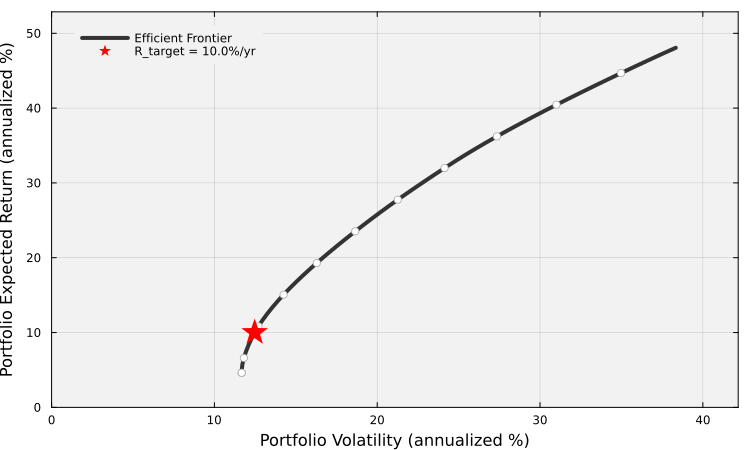


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Chosen portfolio: expected return 10.0%/yr, volatility 12.47%/yr (finance convention)


In [5]:
minvar_result = let

    # --- Step 1: Build the SIM covariance matrix (units: 1/year²) ---
    Σ = build_sim_covariance(sim_estimates, σ_m);

    # --- Step 2: Long-only bounds and the QP ---
    bounds = hcat(zeros(N), ones(N));
    problem = build(MyPortfolioAllocationProblem;
        μ = μ_vec, Σ = Σ, bounds = bounds, R = R_target);

    # --- Step 3: Solve the minimum-variance QP at the target return ---
    mv = solve_minvariance(problem);

    # --- Step 4: Sweep the target return to trace the efficient frontier ---
    R_grid = range(minimum(μ_vec) + 1e-4, 0.99 * maximum(μ_vec), length = 60) |> collect;
    frontier_σ = Float64[];
    frontier_μ = Float64[];
    for R_i ∈ R_grid
        try
            prob_i = build(MyPortfolioAllocationProblem;
                μ = μ_vec, Σ = Σ, bounds = bounds, R = R_i);
            sol = solve_minvariance(prob_i);
            σ_p = sqrt(sol.variance) / sqrt(252) * 100;  # finance vol %/yr
            μ_p = sol.expected_return * 100;             # %/yr
            push!(frontier_σ, σ_p);
            push!(frontier_μ, μ_p);
        catch
            # infeasible — skip
        end
    end

    # --- Step 5: Plot the efficient frontier and star the chosen target ---
    chosen_σ = sqrt(mv.variance) / sqrt(252) * 100;
    chosen_μ = mv.expected_return * 100;
    max_σ = maximum(frontier_σ);
    max_μ = maximum(frontier_μ);
    skip = 5;

    p = plot(frontier_σ, frontier_μ,
        lw = 4, c = :gray20, label = "Efficient Frontier",
        xlabel = "Portfolio Volatility (annualized %)",
        ylabel = "Portfolio Expected Return (annualized %)",
        fontsize = 18,
        xlim = (0.0, 1.1 * max_σ),
        ylim = (0.0, 1.1 * max_μ),
        size = (750, 450));
    scatter!(p, frontier_σ[1:skip:end], frontier_μ[1:skip:end],
        label = "", c = :white, ms = 4, msc = :gray69);
    scatter!(p, [chosen_σ], [chosen_μ],
        marker = :star5, ms = 14, c = :red, msc = :red,
        label = "R_target = $(round(R_target*100, digits=1))%/yr");
    plot!(p, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent,
        legend = :topleft);

    display(p)
    println("Chosen portfolio: expected return $(round(chosen_μ, digits=2))%/yr, "
            * "volatility $(round(chosen_σ, digits=2))%/yr (finance convention)")

    mv
end;

The allocation we will forward-simulate is either the minimum-variance QP solution (default) or the `my_weights` override if set in Task 1. The code below resolves the final weight vector into `allocation_weights::Vector{Float64}` and displays it as a bar chart.

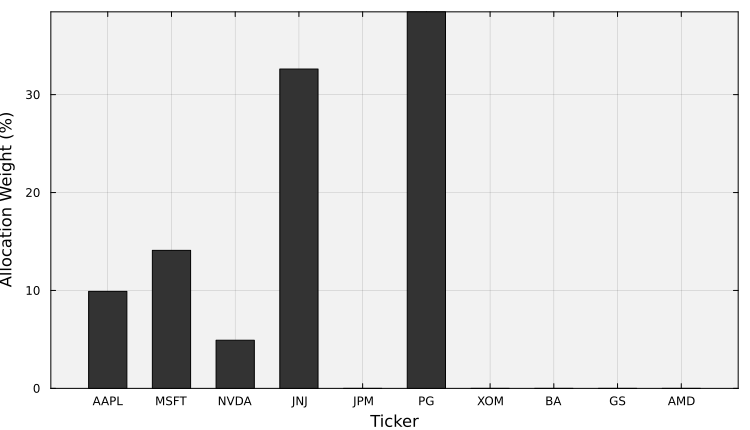

Allocation to forward-simulate:
 -------- ------------
  Ticker   Weight (%) 
  String      Float64 
 -------- ------------
    AAPL         9.91
    MSFT         14.1
    NVDA         4.91
     JNJ        32.62
     JPM          0.0
      PG        38.46
     XOM         -0.0
      BA         -0.0
      GS         -0.0
     AMD         -0.0
 -------- ------------


In [6]:
allocation_weights = let
    # --- Step 1: Resolve weights (QP default vs user override) ---
    w = isnothing(my_weights) ? minvar_result.weights : Float64.(my_weights);
    @assert length(w) == N "my_weights length must equal number of tickers"
    @assert isapprox(sum(w), 1.0; atol=1e-6) "my_weights must sum to 1"

    # --- Step 2: Display the weights as a table ---
    df = DataFrame(
        "Ticker" => my_tickers,
        "Weight (%)" => round.(w .* 100, digits=2)
    );
    println("Allocation to forward-simulate:")
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    # --- Step 3: Bar chart of allocation weights (Varner Lab plot style) ---
    p = bar(my_tickers, w .* 100,
        xlabel = "Ticker",
        ylabel = "Allocation Weight (%)",
        legend = false,
        c = :gray20,
        bar_width = 0.6,
        fontsize = 18,
        size = (750, 430));
    plot!(p, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent);
    display(p)

    w
end;

___
## Task 2: Forward-Simulate the Allocation with Hybrid JumpHMM
We resolve realistic starting prices for each ticker, generate many synthetic futures via the hybrid SIM construction, and visualize a sample of the resulting wealth trajectories before scoring them quantitatively in Task 3.

> __What are we going to do?__
>
> Pull last-day closes from [the `MyCurrentPrices()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyCurrentPrices) so the simulated price paths begin at realistic levels, then call [the `generate_hybrid_scenario(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.generate_hybrid_scenario) to produce `n_paths` Monte Carlo futures composed of a JumpHMM market path, per-ticker HMM idiosyncratic draws (R²-preserving or variance-correcting), and Student-t copula rank-reordering. Visualize sample buy-and-hold wealth trajectories with the median across all paths overlaid.

The starting price for each ticker is the price each ticker has on the first simulated trading day, which determines how many shares the buy-and-hold engine purchases for the given allocation. The `start_prices::Dict{String,Float64}` dictionary built below caches the last available real daily close from the testing OHLC dataset (Polygon S&P 500 data through 2025-12-31) and is handed to the hybrid scenario generator so the simulated price paths begin at realistic levels.

In [7]:
start_prices = let
    snap = MyCurrentPrices();
    snap_lookup = Dict(snap["tickers"] .=> snap["prices"]);
    sp = Dict{String, Float64}()
    for t ∈ my_tickers
        @assert haskey(snap_lookup, t) "Ticker $(t) not in MyCurrentPrices() snapshot"
        sp[t] = snap_lookup[t];
    end

    println("Starting prices for forward simulation (from $(snap["source_label"])):")
    df = DataFrame(
        "Ticker" => my_tickers,
        "Price (\$)" => [round(sp[t], digits=2) for t ∈ my_tickers],
        "As of" => [snap["last_dates"][findfirst(==(t), snap["tickers"])] for t ∈ my_tickers],
    );
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    sp
end;

Starting prices for forward simulation (from polygon-ohlc-testing-dataset):
 -------- ----------- ---------------------
  Ticker   Price ($)                 As of 
  String     Float64                String 
 -------- ----------- ---------------------
    AAPL      271.86   2025-12-31T05:00:00
    MSFT      483.62   2025-12-31T05:00:00
    NVDA       186.5   2025-12-31T05:00:00
     JNJ      206.95   2025-12-31T05:00:00
     JPM      322.22   2025-12-31T05:00:00
      PG      143.31   2025-12-31T05:00:00
     XOM      120.34   2025-12-31T05:00:00
      BA      217.12   2025-12-31T05:00:00
      GS       879.0   2025-12-31T05:00:00
     AMD      214.16   2025-12-31T05:00:00
 -------- ----------- ---------------------


With the starting prices resolved we run the forward Monte Carlo. Each path composes a JumpHMM market growth-rate path with a per-ticker HMM idiosyncratic draw, scales the innovations via either the R²-preserving branch (for tickers whose real-data $R^2 \geq 0.80$) or the marginal-preserving variance correction, and rank-reorders them through the Student-t copula.

> __Hybrid SIM Forward Construction:__
>
> For each of `n_paths` simulations and each ticker in the universe, we compose
>
> $$g_i(t) = \alpha_i + \beta_i\,g_m(t) + \varepsilon_i(t)$$
>
> where:
>
> * $g_m(t)$ is drawn from the [JumpHMM market surrogate](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyMarketSurrogateModel) — a pre-trained model fitted on SPY with regime switching, volatility clustering, and jumps.
> * $\varepsilon_i(t)$ starts as a draw from the ticker's own HMM marginal in [the portfolio surrogate](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyPortfolioSurrogateModel), so it inherits the ticker's heavy tails and clustering. It is then scaled (variance-correcting if $R^2 < 0.80$, $R^2$-preserving otherwise) and copula rank-reordered so cross-sectional dependence matches the Student-t copula fitted on the real universe.
> * The composed growth rate is converted to a price via $p_{t+1} = p_t \exp(g_i(t)\,\Delta t)$.

[The `generate_hybrid_scenario(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.generate_hybrid_scenario) does all of the above in a single call and returns a [`MyBacktestScenario`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.MyBacktestScenario) whose `price_paths` field has shape `(n_paths, n_steps, N)`.

The code below runs the hybrid forward simulation and stores the result in `scenario::MyBacktestScenario`.

In [8]:
scenario = let
    # --- Step 1: Load the surrogate models (cached on disk) ---
    market_model = MyMarketSurrogateModel();
    portfolio    = MyPortfolioSurrogateModel();
    calib        = MySIMCalibration();

    # --- Step 2: Generate the hybrid forward scenario ---
    scen = generate_hybrid_scenario(market_model, portfolio, calib, my_tickers;
        n_paths = n_paths,
        n_steps = n_steps,
        Δt      = Δt,
        start_prices = start_prices,
        label   = "Hybrid-SIM ($(n_steps)d)",
        seed    = 2026);

    # --- Step 3: Sanity check on the output shape ---
    println("scenario.price_paths shape: $(size(scen.price_paths)) "
            * "(n_paths × n_steps × N_tickers)")
    println("scenario.market_paths shape: $(size(scen.market_paths))")

    scen
end;

scenario.price_paths shape: (500, 252, 10) (n_paths × n_steps × N_tickers)
scenario.market_paths shape: (500, 252)


Before we run the scorecard it helps to visually confirm the scenario is reasonable. The code below computes the buy-and-hold wealth trajectory for 15 sampled paths using the allocation we resolved in Task 1 and overlays the median across all paths.

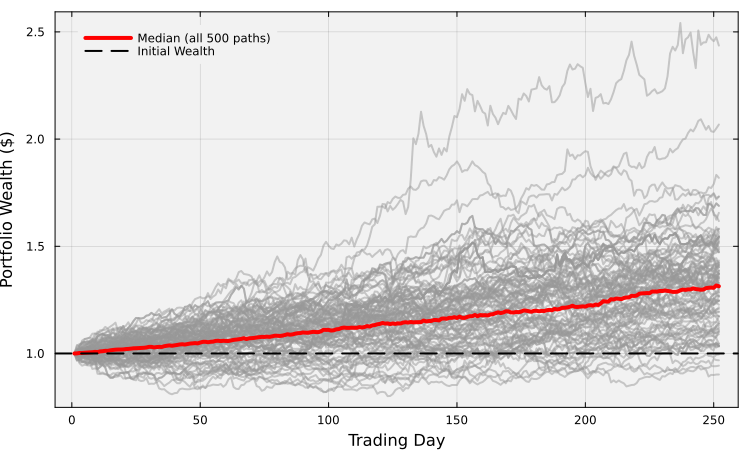

In [18]:
let
    # --- Step 1: Randomly sample 15 paths for visualization ---
    Random.seed!(2027);
    sample_idx = rand(1:scenario.n_paths, 100);
    initial_wealth = B₀;

    # --- Step 2: Compute the buy-and-hold wealth trajectory per sampled path ---
    K = length(my_tickers);
    wealth_sample = zeros(scenario.n_steps, length(sample_idx));
    for (j, p) ∈ enumerate(sample_idx)
        shares = [(B₀ * allocation_weights[k]) / scenario.price_paths[p, 1, k] for k in 1:K];
        for t ∈ 1:scenario.n_steps
            wealth_sample[t, j] = (1/initial_wealth) * sum(shares[k] * scenario.price_paths[p, t, k] for k in 1:K);
        end
    end

    # --- Step 3: Compute the median wealth trajectory across ALL paths ---
    wealth_all = zeros(scenario.n_steps, scenario.n_paths);
    for p ∈ 1:scenario.n_paths
        shares = [(B₀ * allocation_weights[k]) / scenario.price_paths[p, 1, k] for k in 1:K];
        for t ∈ 1:scenario.n_steps
            wealth_all[t, p] = (1/initial_wealth) * sum(shares[k] * scenario.price_paths[p, t, k] for k in 1:K);
        end
    end
    median_trajectory = [median(wealth_all[t, :]) for t ∈ 1:scenario.n_steps];

    # --- Step 4: Plot sample paths + median (Varner Lab plot style) ---
    p = plot(1:scenario.n_steps, wealth_sample,
        lw = 2, c = :gray60, alpha = 0.5, label = "",
        xlabel = "Trading Day",
        ylabel = "Portfolio Wealth (\$)",
        fontsize = 18,
        size = (750, 450));
    plot!(p, 1:scenario.n_steps, median_trajectory,
        lw = 4, c = :red, label = "Median (all $(scenario.n_paths) paths)");
    hline!(p, [B₀/initial_wealth],
        lw = 2, ls = :dash, c = :black, label = "Initial Wealth");
    plot!(p, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent,
        legend = :topleft);
    display(p)
end;

___
## Task 3: Score the Distribution and Hand Off
We hold the allocation buy-and-hold across every simulated path, summarize the resulting distribution of outcomes (terminal wealth, max drawdown, Sharpe ratio, fail rate), visualize the spread with histograms, and persist the allocation plus scorecard to disk so downstream stress-test notebooks can load it directly.

> __Scorecard Metrics:__
>
> * **Median terminal wealth ($W_T$):** the middle outcome across all paths. Matches the "typical future" if simulations were ordered best to worst.
> * **P10 / P90 terminal wealth:** 10th and 90th percentiles. The width `P90 − P10` is a proxy for the spread of possible futures.
> * **Median max drawdown:** the middle worst-peak-to-trough loss across paths.
> * **Median Sharpe ratio:** the middle risk-adjusted return across paths.
> * **Fail rate $P[W_T < B_0]$:** fraction of paths that ended below the initial wealth — a direct measure of "loss probability over the horizon".

> __What are we going to do?__
>
> [The `backtest_buyhold(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.backtest_buyhold) takes the scenario, the tickers, the initial wealth, and the weight vector, and returns a [`MyBacktestResult`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.MyBacktestResult) with per-path terminal wealth, drawdown, and Sharpe arrays. We pass `offset = 1` because the buy happens on day 1 (no warm-up period in this notebook).

The code below runs the buy-and-hold engine and stores the result in `result::MyBacktestResult`.

In [14]:
result = let
    # --- Step 1: Run buy-and-hold across every path ---
    r = backtest_buyhold(scenario, my_tickers;
        B₀      = B₀,
        offset  = 1,                      # buy on day 1
        weights = allocation_weights);

    # --- Step 2: Summarize the terminal wealth / drawdown / Sharpe distributions ---
    scorecard = DataFrame(
        "Metric" => [
            "Median terminal wealth (\$)",
            "P10 terminal wealth (\$)",
            "P90 terminal wealth (\$)",
            "Median max drawdown (%)",
            "Median Sharpe ratio",
            "Fail rate P[W_T < B₀] (%)"
        ],
        "Value" => [
            round(median(r.final_wealth), digits=0),
            round(quantile(r.final_wealth, 0.10), digits=0),
            round(quantile(r.final_wealth, 0.90), digits=0),
            round(median(r.max_drawdowns) * 100, digits=2),
            round(median(r.sharpe_ratios), digits=3),
            round(mean(r.final_wealth .< B₀) * 100, digits=1)
        ]
    );

    println("Buy-and-hold scorecard over $(scenario.n_paths) paths, $(scenario.n_steps)-day horizon:")
    pretty_table(scorecard; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    r
end;

Buy-and-hold scorecard over 500 paths, 252-day horizon:
 ---------------------------- ---------
                      Metric     Value 
                      String   Float64 
 ---------------------------- ---------
  Median terminal wealth ($)   13136.0
     P10 terminal wealth ($)   10359.0
     P90 terminal wealth ($)   16279.0
     Median max drawdown (%)     12.76
         Median Sharpe ratio     1.648
   Fail rate P[W_T < B₀] (%)       7.2
 ---------------------------- ---------


The histograms below show the distributions across paths with the median marked on each.

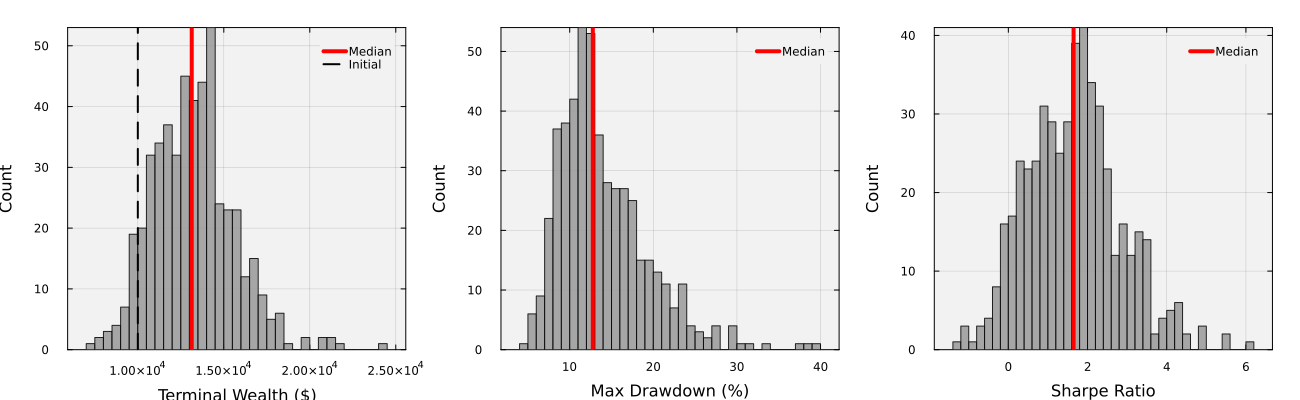

In [15]:
let
    median_wealth = median(result.final_wealth);
    median_dd     = median(result.max_drawdowns);
    median_sharpe = median(result.sharpe_ratios);

    # --- Panel 1: Terminal wealth ---
    p1 = histogram(result.final_wealth, bins = 40, alpha = 0.85, color = :gray60,
        xlabel = "Terminal Wealth (\$)", ylabel = "Count",
        fontsize = 18, label = "");
    vline!(p1, [median_wealth], lw = 4, c = :red, label = "Median");
    vline!(p1, [B₀], lw = 2, ls = :dash, c = :black, label = "Initial");
    plot!(p1, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent);

    # --- Panel 2: Max drawdown ---
    p2 = histogram(result.max_drawdowns .* 100, bins = 40, alpha = 0.85, color = :gray60,
        xlabel = "Max Drawdown (%)", ylabel = "Count",
        fontsize = 18, label = "");
    vline!(p2, [median_dd * 100], lw = 4, c = :red, label = "Median");
    plot!(p2, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent);

    # --- Panel 3: Sharpe ratio ---
    p3 = histogram(result.sharpe_ratios, bins = 40, alpha = 0.85, color = :gray60,
        xlabel = "Sharpe Ratio", ylabel = "Count",
        fontsize = 18, label = "");
    vline!(p3, [median_sharpe], lw = 4, c = :red, label = "Median");
    plot!(p3, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent);

    plot(p1, p2, p3, layout = (1, 3), size = (1300, 400), margin = 5Plots.mm)
end

Finally we persist the allocation, SIM parameters, and the scorecard arrays to disk. The next notebook in this sequence (Stress-Test) will load this file directly instead of re-solving the QP.

The code below saves the handoff file using [the `save_results(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.save_results).

In [16]:
let
    save_path = joinpath(_PATH_TO_DATA, "minvar-allocation.jld2");
    save_results(save_path, Dict(
        "my_tickers"         => my_tickers,
        "allocation_weights" => allocation_weights,
        "sim_estimates"      => sim_estimates,
        "sigma_market"       => σ_m,
        "R_target"           => R_target,
        "final_wealth"       => result.final_wealth,
        "max_drawdowns"      => result.max_drawdowns,
        "sharpe_ratios"      => result.sharpe_ratios,
    ));

    println("Saved minimum-variance allocation to: $(save_path)")
    println("  $(length(my_tickers)) tickers, R_target = $(round(R_target*100, digits=1))%/yr")
    println("  $(length(result.final_wealth)) buy-and-hold scorecard paths")
end;

Saved minimum-variance allocation to: /Users/jdv27/Desktop/julia_work/eCornell-AI-finance-lectures/lectures/session-1/data/minvar-allocation.jld2
  10 tickers, R_target = 10.0%/yr
  500 buy-and-hold scorecard paths


___
## Summary
This example assembled a minimum-variance portfolio on a user-chosen ticker subset from cached SIM calibration, traced the efficient frontier, and forward-simulated the chosen allocation with the hybrid JumpHMM construction to produce a distributional scorecard across buy-and-hold paths.

> __Key Takeaways:__
>
> * __Calibrated SIM closes the synthetic-reality gap:__ Real-data α and β give the QP cross-sectional structure that students can map onto familiar names. The covariance matrix and the forward simulator use the same market volatility σ_m, so the frontier point really is the allocation being stress-tested.
> * __Hybrid forward simulation preserves tails and regimes:__ Composing a JumpHMM market path with per-ticker HMM marginals and a Student-t copula injects fat tails, regime switching, and cross-sectional dependence that a Gaussian SIM cannot reproduce. The resulting scenario is reusable across Session 1 and Session 3.
> * __Scorecards replace point estimates:__ Median terminal wealth, P10 / P90 quantiles, max drawdown, Sharpe ratio, and fail rate across many synthetic futures turn a single allocation into a risk profile. This distributional lens is the framing carried forward into the Stress-Test example.

The saved parameter file is used by downstream notebooks for preference weight computation and covariance construction.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.